In [1]:
# ---------------------------------------------------
#— Load Dataset
# ---------------------------------------------------

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
UTILS_PATH = PROJECT_ROOT / "4_predictive_forecasting" / "utils"

sys.path.append(str(UTILS_PATH))

from data_loader import load_dataset

df = load_dataset()

df.head()


Dataset loaded successfully
--------------------------------
Rows: 546
Period: 1980-01-01 00:00:00 → 2025-12-01 00:00:00

Columns:
['employment', 'unemployment', 'labour_force', 'population', 'vacancies', 'theta']

Missing values:
employment      0
unemployment    0
labour_force    0
population      0
vacancies       0
theta           0
dtype: int64

Summary statistics:
        employment  unemployment  labour_force   population   vacancies  \
count       546.00        546.00        546.00       546.00      546.00   
mean   15373110.07    1299307.33   16672417.40  25238762.27   305316.43   
std     2902418.85     190657.59    2919465.16   4371584.60   182311.44   
min    10764100.00     857700.00   11760100.00  18317900.00    90204.00   
25%    12855650.00    1145275.00   14299250.00  21508550.00   181225.00   
50%    15413000.00    1299400.00   16675800.00  24856950.00   241145.50   
75%    17690325.00    1426800.00   19051150.00  28712150.00   360527.00   
max    21146000.00    1863

,employment,unemployment,labour_force,population,vacancies,theta
month,,,,,,
1980-01-01,10882600,877500,11760100,18317900,273345.0,0.311504
1980-02-01,10902900,894000,11796900,18346400,259678.0,0.290468
1980-03-01,10897800,901000,11798800,18373900,254211.0,0.282143
1980-04-01,10938300,908300,11846600,18407700,256944.0,0.282885
1980-05-01,10891600,923900,11815500,18437000,235077.0,0.254440


In [2]:
# =========================================================
# STEP M1 — MULTIVARIATE SYSTEM DEFINITION
# =========================================================

import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. Create a safe working copy
# ---------------------------------------------------------

multi_df = df.copy()

# Confirm datetime index
multi_df.index = pd.to_datetime(multi_df.index)

print("Multivariate dataset created.")
print("Date range:", multi_df.index.min(), "to", multi_df.index.max())
print("Observations:", len(multi_df))


# ---------------------------------------------------------
# 2. Create log variables for the core multivariate system
# ---------------------------------------------------------

multi_df["log_unemployment"] = np.log(multi_df["unemployment"])
multi_df["log_vacancies"] = np.log(multi_df["vacancies"])

print("\nLog variables created:")
print(["log_unemployment", "log_vacancies"])


# ---------------------------------------------------------
# 3. Build the core two-variable system
# ---------------------------------------------------------

Y_levels = multi_df[["log_unemployment", "log_vacancies"]].copy()

print("\nCore multivariate system (levels) preview:")
display(Y_levels.head())


# ---------------------------------------------------------
# 4. Create first-differenced version for stationary VAR use
# ---------------------------------------------------------

Y_diff = Y_levels.diff().dropna()

print("\nFirst-differenced system created.")
print("Differenced system shape:", Y_diff.shape)

display(Y_diff.head())


# ---------------------------------------------------------
# 5. Keep theta as a derived variable only
# ---------------------------------------------------------

multi_df["theta_derived_check"] = (
    multi_df["vacancies"] / multi_df["unemployment"]
)

theta_check_error = (
    multi_df["theta"] - multi_df["theta_derived_check"]
).abs().max()

print("\nMaximum theta consistency check error:", theta_check_error)


# ---------------------------------------------------------
# 6. Basic summary
# ---------------------------------------------------------

print("\nSummary statistics — levels")
display(Y_levels.describe().round(4))

print("\nSummary statistics — differences")
display(Y_diff.describe().round(4))

Multivariate dataset created.
Date range: 1980-01-01 00:00:00 to 2025-12-01 00:00:00
Observations: 546

Log variables created:
['log_unemployment', 'log_vacancies']

Core multivariate system (levels) preview:


,log_unemployment,log_vacancies
month,,
1980-01-01,13.684832,12.518490
1980-02-01,13.703461,12.467198
1980-03-01,13.711261,12.445920
1980-04-01,13.719330,12.456613
1980-05-01,13.736359,12.367668



First-differenced system created.
Differenced system shape: (545, 2)


,log_unemployment,log_vacancies
month,,
1980-02-01,0.018629,-0.051292
1980-03-01,0.007799,-0.021278
1980-04-01,0.008069,0.010694
1980-05-01,0.017029,-0.088945
1980-06-01,-0.006080,0.000000



Maximum theta consistency check error: 1.1102230246251565e-16

Summary statistics — levels


,log_unemployment,log_vacancies
count,546.0000,546.0000
mean,14.0664,12.4949
std,0.1493,0.4917
min,13.6620,11.4098
25%,13.9512,12.1075
50%,14.0774,12.3932
75%,14.1709,12.7953
max,14.4379,13.8520



Summary statistics — differences


,log_unemployment,log_vacancies
count,545.0000,545.0000
mean,0.0010,0.0008
std,0.0304,0.0724
min,-0.1546,-0.3011
25%,-0.0161,-0.0202
50%,-0.0005,0.0000
75%,0.0149,0.0178
max,0.3438,0.7396


## M2. Multivariate Admissibility Review

Before estimating a multivariate time-series model, it is necessary to determine which econometric framework is appropriate for the joint system of unemployment and vacancies.

The two candidate frameworks are:

### 1. Vector Autoregression (VAR)

A VAR model is appropriate when the modeled variables are stationary. In practice, this usually means estimating the system on transformed stationary series such as first differences of log unemployment and log vacancies.

This approach captures **short-run dynamic interactions** but does not explicitly impose a long-run equilibrium relationship.

### 2. Vector Error Correction Model (VECM)

A VECM is appropriate when the variables are integrated of order one and cointegrated. In this case, the model captures both:

- short-run adjustments
- long-run equilibrium correction

This is especially relevant in labour economics because unemployment and vacancies may be linked through the Beveridge curve.

### Decision logic

The multivariate admissibility review is based on the following criteria:

1. Stationarity properties of the component series  
2. Cointegration evidence from the Johansen test  
3. Practical forecasting stability and interpretability  

If the evidence for cointegration is sufficiently strong, a VECM can be considered. If the integration structure is mixed or cointegration evidence is weak, a VAR on first-differenced log series provides the more defensible benchmark.

This step formalizes the multivariate modeling path before lag-order selection and estimation.

In [3]:
# =========================================================
# STEP M2 — MULTIVARIATE ADMISSIBILITY REVIEW
# =========================================================

import pandas as pd
from statsmodels.tsa.stattools import adfuller

# ---------------------------------------------------------
# 1. Helper function for ADF summary
# ---------------------------------------------------------

def adf_check(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    return {
        "series": name,
        "ADF statistic": result[0],
        "p-value": result[1],
        "used lags": result[2],
        "nobs": result[3],
        "stationary at 5%": result[1] < 0.05
    }

# ---------------------------------------------------------
# 2. Re-check stationarity in levels
# ---------------------------------------------------------

adf_level_u = adf_check(Y_levels["log_unemployment"], "log_unemployment_level")
adf_level_v = adf_check(Y_levels["log_vacancies"], "log_vacancies_level")

levels_adf_table = pd.DataFrame([adf_level_u, adf_level_v])

print("ADF results — level series")
display(levels_adf_table)

# ---------------------------------------------------------
# 3. Re-check stationarity in first differences
# ---------------------------------------------------------

adf_diff_u = adf_check(Y_diff["log_unemployment"], "d_log_unemployment")
adf_diff_v = adf_check(Y_diff["log_vacancies"], "d_log_vacancies")

diff_adf_table = pd.DataFrame([adf_diff_u, adf_diff_v])

print("ADF results — differenced series")
display(diff_adf_table)

# ---------------------------------------------------------
# 4. Summarize earlier Johansen evidence manually
#    Replace these values only if your final Johansen table differs
# ---------------------------------------------------------

johansen_summary = pd.DataFrame({
    "Hypothesis": ["r = 0", "r <= 1"],
    "Trace Statistic": [14.3887, 2.5374],
    "Critical Value (90%)": [13.4294, 2.7055],
    "Critical Value (95%)": [15.4943, 3.8415],
    "Critical Value (99%)": [19.9349, 6.6349]
})

print("Johansen summary (from earlier diagnostic step)")
display(johansen_summary)

# ---------------------------------------------------------
# 5. Admissibility flags
# ---------------------------------------------------------

u_level_stationary = bool(levels_adf_table.loc[levels_adf_table["series"] == "log_unemployment_level", "stationary at 5%"].iloc[0])
v_level_stationary = bool(levels_adf_table.loc[levels_adf_table["series"] == "log_vacancies_level", "stationary at 5%"].iloc[0])

u_diff_stationary = bool(diff_adf_table.loc[diff_adf_table["series"] == "d_log_unemployment", "stationary at 5%"].iloc[0])
v_diff_stationary = bool(diff_adf_table.loc[diff_adf_table["series"] == "d_log_vacancies", "stationary at 5%"].iloc[0])

vecm_90 = johansen_summary.loc[johansen_summary["Hypothesis"] == "r = 0", "Trace Statistic"].iloc[0] > johansen_summary.loc[johansen_summary["Hypothesis"] == "r = 0", "Critical Value (90%)"].iloc[0]
vecm_95 = johansen_summary.loc[johansen_summary["Hypothesis"] == "r = 0", "Trace Statistic"].iloc[0] > johansen_summary.loc[johansen_summary["Hypothesis"] == "r = 0", "Critical Value (95%)"].iloc[0]

decision_table = pd.DataFrame({
    "Criterion": [
        "log_unemployment stationary in levels",
        "log_vacancies stationary in levels",
        "d_log_unemployment stationary",
        "d_log_vacancies stationary",
        "Cointegration supported at 90%",
        "Cointegration supported at 95%"
    ],
    "Result": [
        u_level_stationary,
        v_level_stationary,
        u_diff_stationary,
        v_diff_stationary,
        vecm_90,
        vecm_95
    ]
})

print("Multivariate admissibility decision table")
display(decision_table)

ADF results — level series


,series,ADF statistic,p-value,used lags,nobs,stationary at 5%
0,log_unemployment_level,-4.514516,0.000185,17,528,True
1,log_vacancies_level,-1.857083,0.352512,19,526,False


ADF results — differenced series


,series,ADF statistic,p-value,used lags,nobs,stationary at 5%
0,d_log_unemployment,-5.976588,1.881174e-07,16,528,True
1,d_log_vacancies,-4.935117,2.978155e-05,18,526,True


Johansen summary (from earlier diagnostic step)


,Hypothesis,Trace Statistic,Critical Value (90%),Critical Value (95%),Critical Value (99%)
0,r = 0,14.3887,13.4294,15.4943,19.9349
1,r <= 1,2.5374,2.7055,3.8415,6.6349


Multivariate admissibility decision table


,Criterion,Result
0,log_unemployment stationary in levels,True
1,log_vacancies stationary in levels,False
2,d_log_unemployment stationary,True
3,d_log_vacancies stationary,True
4,Cointegration supported at 90%,True
5,Cointegration supported at 95%,False


In [4]:
# =========================================================
# STEP M2B — FINAL MULTIVARIATE SYSTEM
# =========================================================

multi_system = pd.DataFrame({
    "log_unemployment": multi_df["log_unemployment"],
    "d_log_vacancies": multi_df["log_vacancies"].diff()
})

multi_system = multi_system.dropna()

print("Final multivariate system shape:", multi_system.shape)

display(multi_system.head())

Final multivariate system shape: (545, 2)


,log_unemployment,d_log_vacancies
month,,
1980-02-01,13.703461,-0.051292
1980-03-01,13.711261,-0.021278
1980-04-01,13.719330,0.010694
1980-05-01,13.736359,-0.088945
1980-06-01,13.730279,0.000000


## M3. Lag Order Selection for the VAR System

Before estimating the vector autoregression model, the appropriate lag length must be determined.

Selecting the correct lag order is critical because it determines how much past information is incorporated into the system dynamics. An insufficient lag length may omit important serial dependence, while an excessively large lag structure can introduce overfitting and reduce estimation efficiency.

Lag order selection is performed using several information criteria:

- Akaike Information Criterion (AIC)
- Bayesian Information Criterion (BIC)
- Hannan–Quinn Information Criterion (HQIC)
- Final Prediction Error (FPE)

Each criterion balances model fit against model complexity. In macroeconomic applications, BIC often favors more parsimonious models, while AIC may select slightly longer lag structures that capture richer dynamics.

The optimal lag order will be chosen based on the joint evidence of these criteria while maintaining model parsimony.

In [5]:
# =========================================================
# STEP M3 — VAR LAG ORDER SELECTION
# =========================================================

from statsmodels.tsa.api import VAR

# Initialize VAR model
var_model = VAR(multi_system)

# Test lags up to 12 months (1 year)
lag_selection = var_model.select_order(maxlags=12)

print(lag_selection.summary())

c:\Users\Anurodh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -9.179      -9.163   0.0001032      -9.173
1       -12.25     -12.20*   4.787e-06      -12.23
2       -12.27      -12.19   4.711e-06      -12.23
3       -12.28      -12.17   4.653e-06      -12.23
4       -12.33      -12.19   4.405e-06      -12.28
5       -12.36      -12.18   4.290e-06      -12.29
6       -12.37      -12.16   4.229e-06      -12.29
7       -12.37      -12.13   4.236e-06      -12.28
8       -12.39      -12.12   4.164e-06      -12.28
9       -12.40      -12.09   4.119e-06      -12.28
10      -12.41      -12.07   4.095e-06      -12.27
11      -12.42      -12.05   4.047e-06      -12.27
12     -12.50*      -12.10  3.717e-06*     -12.35*
--------------------------------------------------


## M4. VAR Model Estimation

After determining the optimal lag order, the multivariate system is estimated using a vector autoregression (VAR) model.

The estimated system takes the form:

\[
Y_t = A_1 Y_{t-1} + A_2 Y_{t-2} + \dots + A_{12} Y_{t-12} + \varepsilon_t
\]

where

\[
Y_t =
\begin{bmatrix}
\log(U_t) \\
\Delta \log(V_t)
\end{bmatrix}
\]

The VAR framework allows each variable to depend on its own past values and the past values of the other variable, capturing the dynamic interaction between unemployment and vacancy growth.

Estimating the system provides:

- coefficient matrices describing dynamic interactions
- fitted values
- residuals for diagnostic testing
- a basis for impulse response analysis and forecasting

In [6]:
# =========================================================
# STEP M4 — VAR MODEL ESTIMATION
# =========================================================

from statsmodels.tsa.api import VAR

# initialize VAR model
var_model = VAR(multi_system)

# estimate VAR with 12 lags
var_results = var_model.fit(12)

print(var_results.summary())

c:\Users\Anurodh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 09, Mar, 2026
Time:                     16:22:58
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -12.1014
Nobs:                     533.000    HQIC:                  -12.3457
Log likelihood:           1869.39    FPE:                3.71696e-06
AIC:                     -12.5027    Det(Omega_mle):     3.39136e-06
--------------------------------------------------------------------
Results for equation log_unemployment
                          coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------------
const                        0.528974         0.140474            3.766           0.000
L1.log_unemployment          1.063811         0.044539           23.885           0.000
L1.d_log_vacancies   

In [7]:
# =========================================================
# STEP M5 — VAR STABILITY CHECK
# =========================================================

stability = var_results.is_stable()

print("Is the VAR stable?", stability)

roots = var_results.roots

print("\nEigenvalues of the VAR system:")
print(roots)

Is the VAR stable? True

Eigenvalues of the VAR system:
[-7.18152475e+00-0.j          1.35536475e+00+0.11871114j
  1.35536475e+00-0.11871114j -6.55336358e-01+1.15434812j
 -6.55336358e-01-1.15434812j  8.23862829e-01-0.90674006j
  8.23862829e-01+0.90674006j -1.10612633e+00+0.43072096j
 -1.10612633e+00-0.43072096j  4.05586541e-03-1.14238199j
  4.05586541e-03+1.14238199j -9.88238756e-01+0.56941581j
 -9.88238756e-01-0.56941581j -1.13003006e+00-0.j
 -6.39351725e-01-0.90407467j -6.39351725e-01+0.90407467j
  9.52790949e-01+0.55002996j  9.52790949e-01-0.55002996j
 -8.91007693e-02-1.09513966j -8.91007693e-02+1.09513966j
  1.05882607e+00-0.08389583j  1.05882607e+00+0.08389583j
  4.99188105e-01+0.91749304j  4.99188105e-01-0.91749304j]


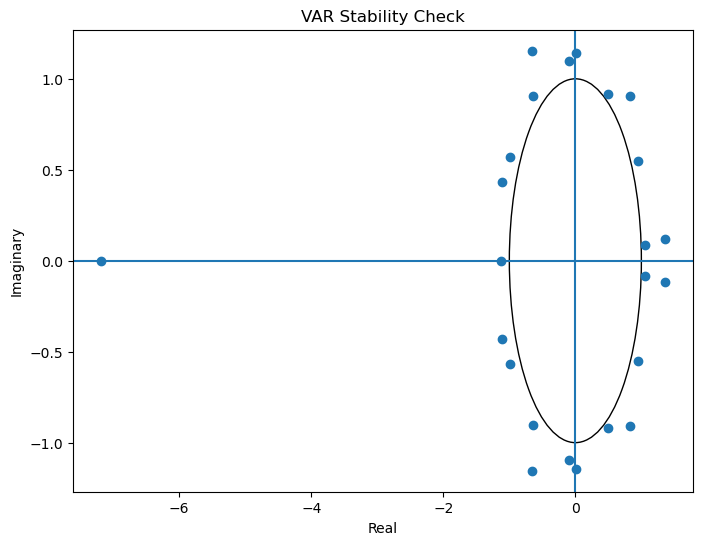

In [15]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

circle = plt.Circle((0,0),1,color='black',fill=False)
plt.gca().add_patch(circle)

plt.scatter(np.real(roots), np.imag(roots))

plt.title("VAR Stability Check")
plt.xlabel("Real")
plt.ylabel("Imaginary")

plt.axhline(0)
plt.axvline(0)

plt.show()

## M6. Granger Causality Analysis

Granger causality tests whether past values of one variable contain useful information for predicting another variable.

In the labour market context, the following hypotheses are examined:

1. Vacancy growth does not Granger-cause unemployment.
2. Unemployment does not Granger-cause vacancy growth.

Rejecting the null hypothesis indicates that lagged values of one variable improve prediction of the other variable, suggesting directional influence within the labour market system.

These tests help determine whether labour demand indicators (vacancies) lead labour supply outcomes (unemployment) or whether the relationship operates in both directions.

In [9]:
# =========================================================
# STEP M6 — GRANGER CAUSALITY TESTS
# =========================================================

# Does vacancy growth help predict unemployment?
gc_v_to_u = var_results.test_causality(
    caused="log_unemployment",
    causing=["d_log_vacancies"],
    kind="f"
)

print("\nVacancies → Unemployment")
print(gc_v_to_u.summary())


# Does unemployment help predict vacancy growth?
gc_u_to_v = var_results.test_causality(
    caused="d_log_vacancies",
    causing=["log_unemployment"],
    kind="f"
)

print("\nUnemployment → Vacancies")
print(gc_u_to_v.summary())


Vacancies → Unemployment
Granger causality F-test. H_0: d_log_vacancies does not Granger-cause log_unemployment. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value     df    
------------------------------------------------
         2.720          1.762   0.001 (12, 1016)
------------------------------------------------

Unemployment → Vacancies
Granger causality F-test. H_0: log_unemployment does not Granger-cause d_log_vacancies. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value     df    
------------------------------------------------
         3.029          1.762   0.000 (12, 1016)
------------------------------------------------


## M7. Impulse Response Analysis

Impulse response functions trace the dynamic effects of a one-time shock to one variable on the current and future values of the variables in the VAR system.

In the labour market context, impulse responses allow us to examine how shocks to vacancy growth or unemployment propagate through the system over time.

The analysis focuses on two key shocks:

1. A shock to vacancy growth and its effect on unemployment.
2. A shock to unemployment and its effect on vacancy growth.

These responses reveal the adjustment dynamics of the labour market and help identify whether demand-side or supply-side shocks dominate the system.

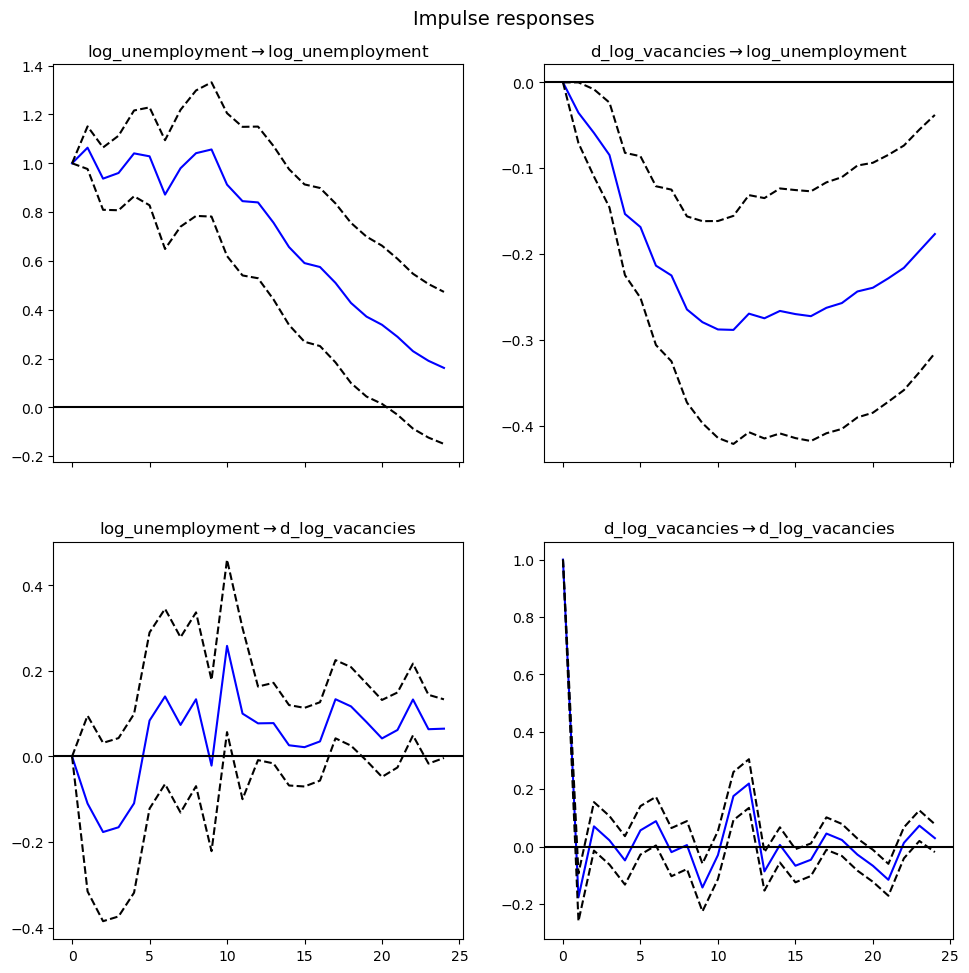

In [10]:
# =========================================================
# STEP M7 — IMPULSE RESPONSE FUNCTIONS
# =========================================================

irf = var_results.irf(24)   # 24 months horizon

irf.plot()

plt.show()

## M8. Forecast Error Variance Decomposition (FEVD)

Forecast Error Variance Decomposition measures the proportion of the forecast error variance of each variable that is attributable to shocks in each variable within the system.

While impulse response functions illustrate the direction and persistence of dynamic responses, FEVD quantifies the relative importance of different shocks in driving fluctuations in the variables.

In the context of the labour market system, the FEVD analysis helps determine whether unemployment fluctuations are primarily driven by labour demand shocks (vacancies) or by shocks originating within unemployment itself.

The decomposition is calculated over a 24-month horizon to capture both short-run and medium-run dynamics of labour market adjustment.

In [11]:
# =========================================================
# STEP M8 — FORECAST ERROR VARIANCE DECOMPOSITION
# =========================================================

# Compute FEVD
fevd = var_results.fevd(24)

# Print FEVD tables
print("\nVariance Decomposition:")
print(fevd.summary())


Variance Decomposition:
FEVD for log_unemployment
      log_unemployment  d_log_vacancies
0             1.000000         0.000000
1             0.996801         0.003199
2             0.991557         0.008443
3             0.983952         0.016048
4             0.963670         0.036330
5             0.947228         0.052772
6             0.922303         0.077697
7             0.903086         0.096914
8             0.881475         0.118525
9             0.862817         0.137183
10            0.843707         0.156293
11            0.826596         0.173404
12            0.814881         0.185119
13            0.802449         0.197551
14            0.790806         0.209194
15            0.778794         0.221206
16            0.767263         0.232737
17            0.756734         0.243266
18            0.746414         0.253586
19            0.737272         0.262728
20            0.728585         0.271415
21            0.720698         0.279302
22            0.713537       

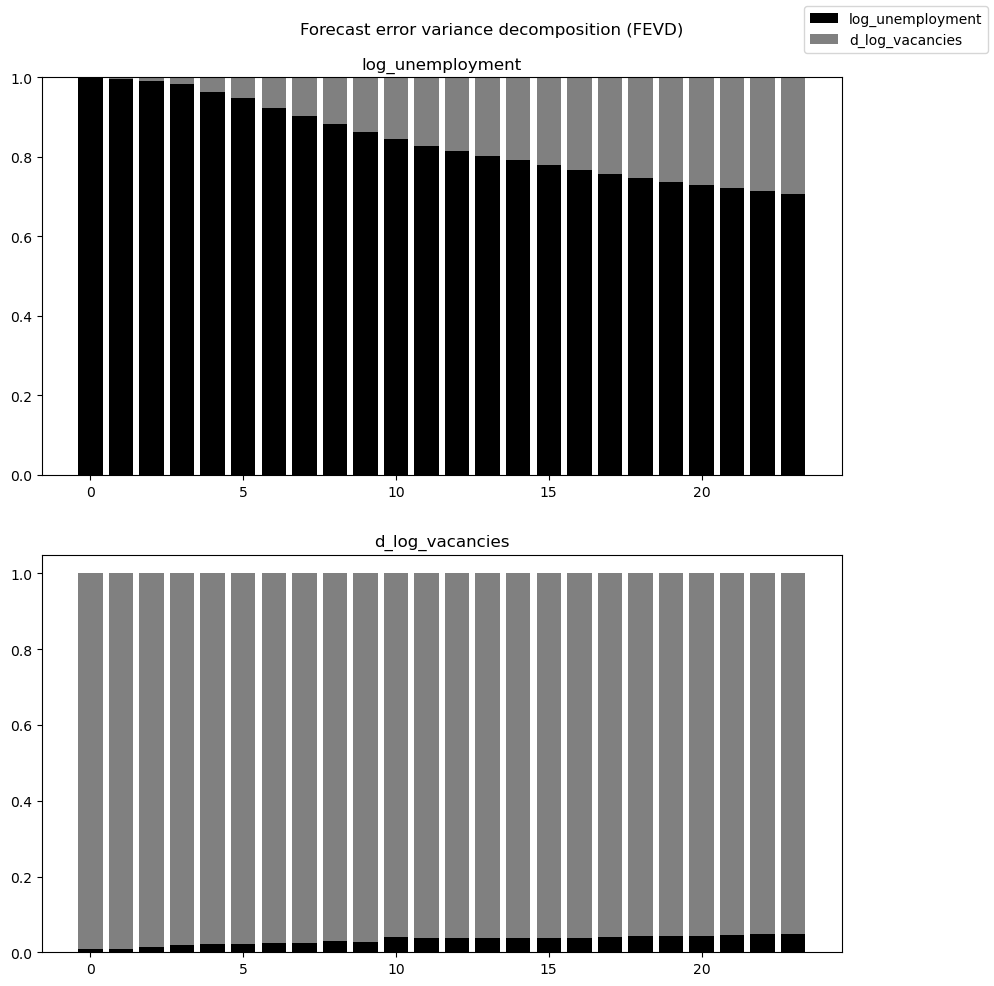

In [12]:
# =========================================================
# FEVD Plot
# =========================================================

fevd.plot()

plt.show()

In [14]:
# =========================================================
# STEP M9 — STRUCTURAL VAR (SVAR via Cholesky Identification)
# =========================================================

from statsmodels.tsa.api import VAR

# Use the dataset already used for VAR
svar_data = var_model.endog.copy()

# Reorder variables for structural identification
# Economic logic:
# Vacancy shocks occur first (labour demand)
# Unemployment adjusts afterward
svar_data = svar_data[:, [1, 0]]  # Reorder to [d_log_vacancies, log_unemployment]

# Estimate VAR again with same lag length
svar_model = VAR(svar_data)

svar_results = svar_model.fit(12)

print(svar_results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 09, Mar, 2026
Time:                     16:49:27
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -12.1014
Nobs:                     533.000    HQIC:                  -12.3457
Log likelihood:           1869.39    FPE:                3.71696e-06
AIC:                     -12.5027    Det(Omega_mle):     3.39136e-06
--------------------------------------------------------------------
Results for equation y1
            coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------
const         -0.997264         0.330606           -3.016           0.003
L1.y1         -0.176728         0.042496           -4.159           0.000
L1.y2         -0.109992         0.104823           -1.049           0.294
L2.y1          0.

VAR train shape: (509, 2)
VAR test shape : (36, 2)
Train period   : 1980-02-01 00:00:00 to 2022-12-01 00:00:00
Test period    : 2023-01-01 00:00:00 to 2025-12-01 00:00:00

Lag selection summary:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -12.19     -12.18*   5.058e-06      -12.19
1       -12.22      -12.17   4.915e-06      -12.20
2       -12.23      -12.15   4.878e-06      -12.20
3       -12.24      -12.12   4.828e-06      -12.19
4       -12.29      -12.14   4.581e-06      -12.23
5       -12.28      -12.10   4.634e-06      -12.21
6       -12.31      -12.09   4.492e-06      -12.23
7       -12.32      -12.07   4.459e-06      -12.22
8       -12.31      -12.02   4.503e-06      -12.20
9       -12.32      -12.00   4.461e-06      -12.19
10      -12.34      -11.99   4.352e-06      -12.21
11      -12.35      -11.96   4.329e-06      -12.20
12     -12.43*      -12.01  3.999e-06*  

c:\Users\Anurodh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Anurodh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,actual_unemployment,actual_vacancies,actual_theta,forecast_d_log_unemployment,forecast_d_log_vacancies,forecast_log_unemployment,forecast_log_vacancies,forecast_unemployment,forecast_vacancies,forecast_theta
month,,,,,,,,,,
2023-01-01,1083700,788280.0,0.727397,-0.001918,-0.040088,13.863430,13.490837,1.049086e+06,722762.000775,0.688945
2023-02-01,1096300,747720.0,0.682040,0.015570,0.008315,13.879000,13.499152,1.065548e+06,728797.170926,0.683965
2023-03-01,1079200,790370.0,0.732367,0.035426,0.050563,13.914427,13.549715,1.103973e+06,766594.995389,0.694397
2023-04-01,1080700,839950.0,0.777228,0.023787,-0.007640,13.938213,13.542075,1.130547e+06,760760.338829,0.672914
2023-05-01,1111300,812510.0,0.731135,0.025437,-0.035999,13.963650,13.506076,1.159673e+06,733860.617704,0.632817



VAR metrics summary:


,model,target,RMSE,MAE,MAPE,sMAPE,MASE,train_end_date,test_start_date,test_end_date,selected_lag,lag_criterion
0,VAR,unemployment,212873.684625,172306.094380,11.644977,12.712824,5.898585,2022-12-01,2023-01-01,2025-12-01,12,AIC
1,VAR,vacancies,138110.184484,117247.385852,22.228588,19.124081,3.726787,2022-12-01,2023-01-01,2025-12-01,12,AIC
2,VAR,theta,0.168868,0.144330,40.293751,30.978349,5.068137,2022-12-01,2023-01-01,2025-12-01,12,AIC



Standardized export preview:


,model_name,target,origin_date,train_end_date,forecast_date,forecast_horizon,predicted_value,actual_value
0,VAR,unemployment,2022-12-01,2022-12-01,2023-01-01,1,1.049086e+06,1083700.0
1,VAR,unemployment,2022-12-01,2022-12-01,2023-02-01,2,1.065548e+06,1096300.0
2,VAR,unemployment,2022-12-01,2022-12-01,2023-03-01,3,1.103973e+06,1079200.0
3,VAR,unemployment,2022-12-01,2022-12-01,2023-04-01,4,1.130547e+06,1080700.0
4,VAR,unemployment,2022-12-01,2022-12-01,2023-05-01,5,1.159673e+06,1111300.0
5,VAR,unemployment,2022-12-01,2022-12-01,2023-06-01,6,1.171418e+06,1153200.0
6,VAR,unemployment,2022-12-01,2022-12-01,2023-07-01,7,1.185075e+06,1172200.0
7,VAR,unemployment,2022-12-01,2022-12-01,2023-08-01,8,1.187246e+06,1164700.0
8,VAR,unemployment,2022-12-01,2022-12-01,2023-09-01,9,1.197886e+06,1181400.0
9,VAR,unemployment,2022-12-01,2022-12-01,2023-10-01,10,1.208646e+06,1235900.0


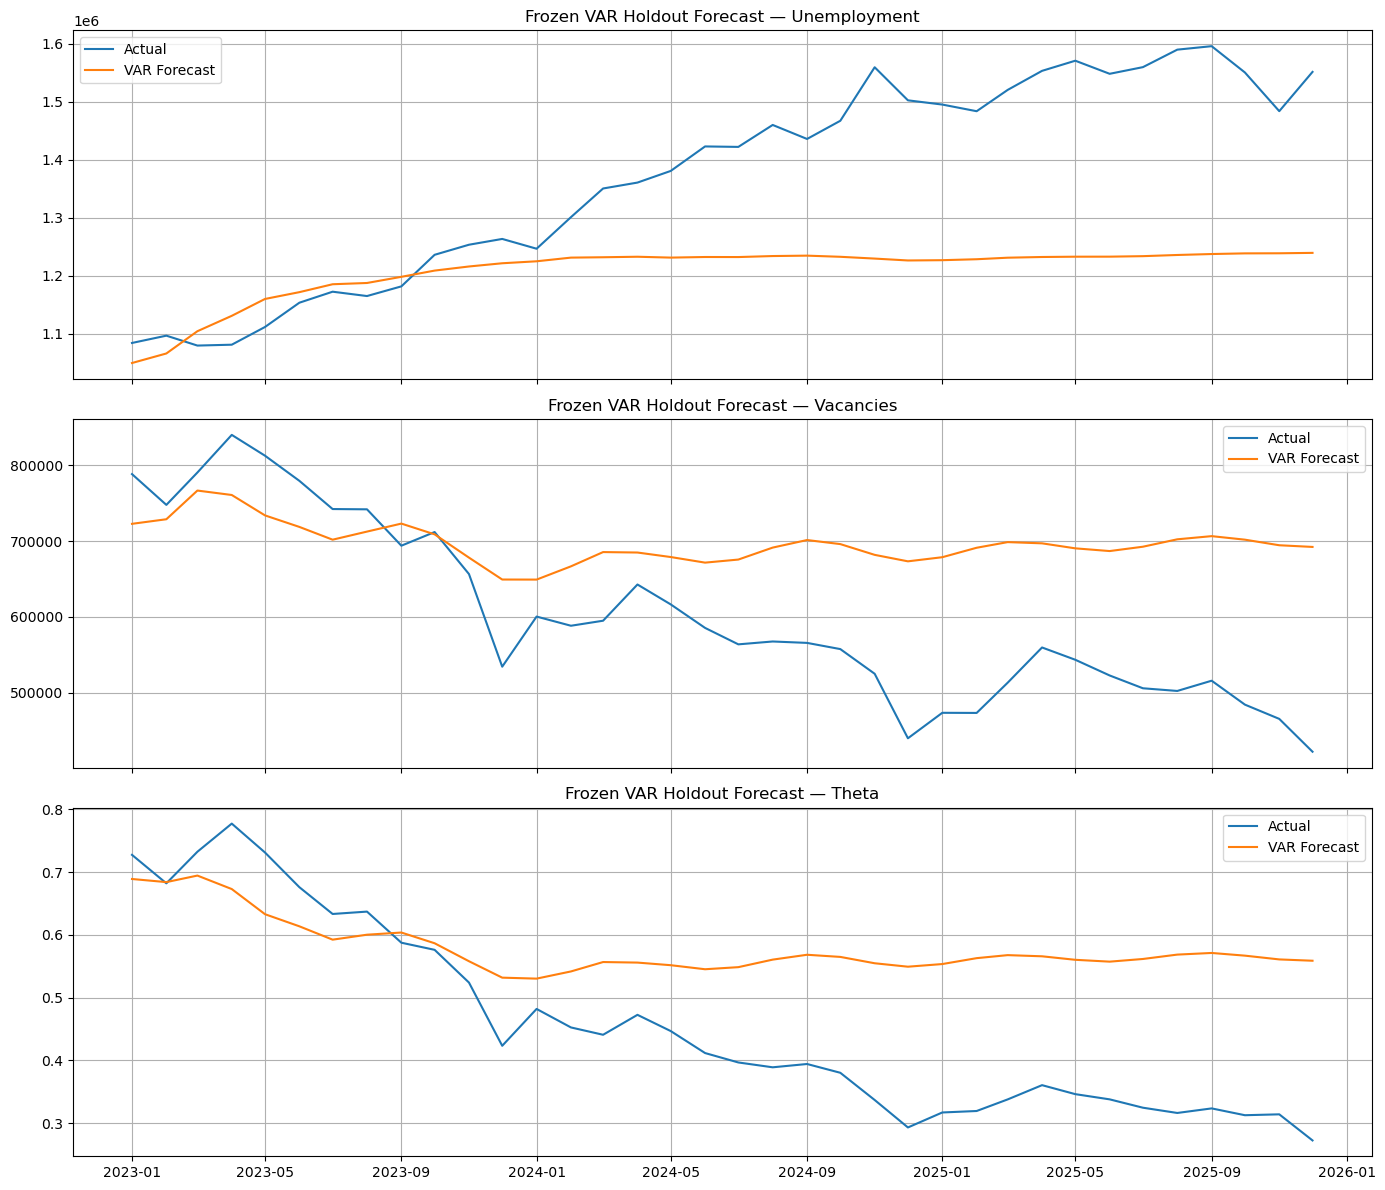


Freeze completed for VAR holdout stage.
Artifacts available in memory:
 - var_results_table       (wide comparison table)
 - var_metrics_df          (metrics by target)
 - var_forecast_export     (standardized long-format export)


In [27]:
# =========================================================
# STEP M10–M11 — FROZEN VAR HOLDOUT FORECAST, METRICS, EXPORT
# =========================================================
# Purpose
# -------
# This is the official frozen VAR holdout cell for the base-model stage.
# It replaces the old forecast + metrics cells and standardizes the output
# for later rolling-origin backtesting and ensemble modeling.
#
# Design choices
# --------------
# 1. Symmetric stationary system:
#       d_log_unemployment, d_log_vacancies
# 2. Train/test split:
#       train through 2022-12-01
#       test from 2023-01-01 onward
# 3. Lag order:
#       selected by information criterion on TRAIN only
# 4. Forecast targets in levels:
#       unemployment, vacancies, theta
# 5. Standard export contract:
#       model_name, target, origin_date, train_end_date,
#       forecast_date, forecast_horizon, predicted_value, actual_value
#
# Notes
# -----
# - This cell is self-contained.
# - It does not depend on the earlier asymmetric VAR definition.
# - It is safe to run after the loader is available in the notebook environment.
# =========================================================

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.api import VAR

# ---------------------------------------------------------
# 0. Safe import of canonical loader
# ---------------------------------------------------------
try:
    load_dataset
except NameError:
    PROJECT_ROOT = Path.cwd().parents[1]
    UTILS_PATH = PROJECT_ROOT / "4_predictive_forecasting" / "utils"
    if str(UTILS_PATH) not in sys.path:
        sys.path.append(str(UTILS_PATH))
    from data_loader import load_dataset

# ---------------------------------------------------------
# 1. Global freeze contract
# ---------------------------------------------------------
MODEL_NAME = "VAR"
TRAIN_END = "2022-12-01"
TEST_START = "2023-01-01"
MAX_LAGS = 12
LAG_CRITERION = "aic"   # freeze criterion here; do not change later

# ---------------------------------------------------------
# 2. Load canonical dataset
# ---------------------------------------------------------
df = load_dataset(verbose=False).copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

required_cols = ["unemployment", "vacancies", "theta"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in dataset: {missing_cols}")

# ---------------------------------------------------------
# 3. Create transformed variables
#    Use log1p for numerical safety
# ---------------------------------------------------------
df["log_unemployment"] = np.log1p(df["unemployment"])
df["log_vacancies"] = np.log1p(df["vacancies"])

# Symmetric stationary VAR system
df["d_log_unemployment"] = df["log_unemployment"].diff()
df["d_log_vacancies"] = df["log_vacancies"].diff()

var_system = df[["d_log_unemployment", "d_log_vacancies"]].dropna().copy()

# ---------------------------------------------------------
# 4. Train / test split
# ---------------------------------------------------------
var_train = var_system.loc[:TRAIN_END].copy()
var_test = var_system.loc[TEST_START:].copy()

if var_train.empty:
    raise ValueError("Training sample is empty. Check TRAIN_END.")
if var_test.empty:
    raise ValueError("Test sample is empty. Check TEST_START.")

print("VAR train shape:", var_train.shape)
print("VAR test shape :", var_test.shape)
print("Train period   :", var_train.index.min(), "to", var_train.index.max())
print("Test period    :", var_test.index.min(), "to", var_test.index.max())

# ---------------------------------------------------------
# 5. Lag order selection on TRAIN only
# ---------------------------------------------------------
lag_selector = VAR(var_train)
lag_selection = lag_selector.select_order(maxlags=MAX_LAGS)

selected_lag = getattr(lag_selection, LAG_CRITERION, None)

# Fallback in case criterion returns None
if selected_lag is None or not isinstance(selected_lag, (int, np.integer)) or selected_lag < 1:
    candidate_lags = {
        "aic": lag_selection.aic,
        "bic": lag_selection.bic,
        "hqic": lag_selection.hqic,
        "fpe": lag_selection.fpe,
    }
    selected_lag = next(
        (v for v in candidate_lags.values() if isinstance(v, (int, np.integer)) and v >= 1),
        1
    )

selected_lag = int(selected_lag)

print("\nLag selection summary:")
print(lag_selection.summary())
print(f"\nSelected lag ({LAG_CRITERION.upper()}):", selected_lag)

# ---------------------------------------------------------
# 6. Fit frozen VAR on TRAIN only
# ---------------------------------------------------------
var_model = VAR(var_train)
var_results = var_model.fit(selected_lag)

print("\nEstimated VAR summary:")
print(var_results.summary())

# ---------------------------------------------------------
# 7. Multi-step holdout forecast on transformed system
# ---------------------------------------------------------
forecast_input = var_train.values[-selected_lag:]

var_forecast_array = var_results.forecast(
    y=forecast_input,
    steps=len(var_test)
)

var_forecast_transformed = pd.DataFrame(
    var_forecast_array,
    index=var_test.index,
    columns=["forecast_d_log_unemployment", "forecast_d_log_vacancies"]
)

# ---------------------------------------------------------
# 8. Reconstruct log levels from differenced forecasts
# ---------------------------------------------------------
last_log_u_train = df.loc[pd.to_datetime(TRAIN_END), "log_unemployment"]
last_log_v_train = df.loc[pd.to_datetime(TRAIN_END), "log_vacancies"]

var_forecast_transformed["forecast_log_unemployment"] = (
    last_log_u_train + var_forecast_transformed["forecast_d_log_unemployment"].cumsum()
)

var_forecast_transformed["forecast_log_vacancies"] = (
    last_log_v_train + var_forecast_transformed["forecast_d_log_vacancies"].cumsum()
)

# ---------------------------------------------------------
# 9. Convert forecasts back to levels
#    Because logs were created with log1p, invert with expm1
# ---------------------------------------------------------
var_forecast_transformed["forecast_unemployment"] = np.expm1(
    var_forecast_transformed["forecast_log_unemployment"]
)

var_forecast_transformed["forecast_vacancies"] = np.expm1(
    var_forecast_transformed["forecast_log_vacancies"]
)

# Guard against tiny negative values from numeric noise
var_forecast_transformed["forecast_unemployment"] = var_forecast_transformed["forecast_unemployment"].clip(lower=0)
var_forecast_transformed["forecast_vacancies"] = var_forecast_transformed["forecast_vacancies"].clip(lower=0)

# ---------------------------------------------------------
# 10. Derive theta forecast
# ---------------------------------------------------------
var_forecast_transformed["forecast_theta"] = np.where(
    var_forecast_transformed["forecast_unemployment"] > 0,
    var_forecast_transformed["forecast_vacancies"] / var_forecast_transformed["forecast_unemployment"],
    np.nan
)

# ---------------------------------------------------------
# 11. Actual comparison table
# ---------------------------------------------------------
actual_compare = pd.DataFrame(index=var_test.index)
actual_compare["actual_unemployment"] = df.loc[var_test.index, "unemployment"]
actual_compare["actual_vacancies"] = df.loc[var_test.index, "vacancies"]
actual_compare["actual_theta"] = df.loc[var_test.index, "theta"]

var_results_table = actual_compare.join(var_forecast_transformed)

print("\nForecast table preview:")
display(var_results_table.head())

# ---------------------------------------------------------
# 12. Standard forecasting metrics
# ---------------------------------------------------------
def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def safe_smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]) * 100

def safe_mase(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) < 2:
        return np.nan
    naive_denom = np.mean(np.abs(np.diff(y_true)))
    if naive_denom == 0:
        return np.nan
    mae = np.mean(np.abs(y_true - y_pred))
    return mae / naive_denom

metric_rows = []

target_specs = {
    "unemployment": ("actual_unemployment", "forecast_unemployment"),
    "vacancies": ("actual_vacancies", "forecast_vacancies"),
    "theta": ("actual_theta", "forecast_theta"),
}

for target_name, (actual_col, forecast_col) in target_specs.items():
    y_true = var_results_table[actual_col].values
    y_pred = var_results_table[forecast_col].values

    row = {
        "model": MODEL_NAME,
        "target": target_name,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": safe_mape(y_true, y_pred),
        "sMAPE": safe_smape(y_true, y_pred),
        "MASE": safe_mase(y_true, y_pred),
        "train_end_date": pd.to_datetime(TRAIN_END),
        "test_start_date": pd.to_datetime(TEST_START),
        "test_end_date": var_results_table.index.max(),
        "selected_lag": selected_lag,
        "lag_criterion": LAG_CRITERION.upper()
    }
    metric_rows.append(row)

var_metrics_df = pd.DataFrame(metric_rows)

print("\nVAR metrics summary:")
display(var_metrics_df)

# ---------------------------------------------------------
# 13. Standardized long-format export contract
# ---------------------------------------------------------
export_frames = []

for target_name, (actual_col, forecast_col) in target_specs.items():
    temp = pd.DataFrame({
        "model_name": MODEL_NAME,
        "target": target_name,
        "origin_date": pd.to_datetime(TRAIN_END),
        "train_end_date": pd.to_datetime(TRAIN_END),
        "forecast_date": var_results_table.index,
        "forecast_horizon": np.arange(1, len(var_results_table) + 1),
        "predicted_value": var_results_table[forecast_col].values,
        "actual_value": var_results_table[actual_col].values
    })
    export_frames.append(temp)

var_forecast_export = pd.concat(export_frames, ignore_index=True)

print("\nStandardized export preview:")
display(var_forecast_export.head(10))

# ---------------------------------------------------------
# 14. Optional CSV exports
#    Uncomment if you want to save immediately
# ---------------------------------------------------------
# EXPORT_DIR = Path.cwd().parent / "exports"
# EXPORT_DIR.mkdir(parents=True, exist_ok=True)
# var_results_table.to_csv(EXPORT_DIR / "var_holdout_results_wide.csv", index=True)
# var_metrics_df.to_csv(EXPORT_DIR / "var_holdout_metrics.csv", index=False)
# var_forecast_export.to_csv(EXPORT_DIR / "var_holdout_forecasts_long.csv", index=False)

# ---------------------------------------------------------
# 15. Visual diagnostics
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(var_results_table.index, var_results_table["actual_unemployment"], label="Actual")
axes[0].plot(var_results_table.index, var_results_table["forecast_unemployment"], label="VAR Forecast")
axes[0].set_title("Frozen VAR Holdout Forecast — Unemployment")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(var_results_table.index, var_results_table["actual_vacancies"], label="Actual")
axes[1].plot(var_results_table.index, var_results_table["forecast_vacancies"], label="VAR Forecast")
axes[1].set_title("Frozen VAR Holdout Forecast — Vacancies")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(var_results_table.index, var_results_table["actual_theta"], label="Actual")
axes[2].plot(var_results_table.index, var_results_table["forecast_theta"], label="VAR Forecast")
axes[2].set_title("Frozen VAR Holdout Forecast — Theta")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 16. Final freeze message
# ---------------------------------------------------------
print("\nFreeze completed for VAR holdout stage.")
print("Artifacts available in memory:")
print(" - var_results_table       (wide comparison table)")
print(" - var_metrics_df          (metrics by target)")
print(" - var_forecast_export     (standardized long-format export)")

In [31]:
# =============================================================================
# EXPORT VAR TEST PREDICTIONS FOR FINAL COMPARISON
# =============================================================================

from pathlib import Path
import pandas as pd

EXPORT_DIR = Path("exports/test_predictions")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

df = var_forecast_export.copy()

targets = ["unemployment", "vacancies", "theta"]

for target in targets:

    temp = df[df["target"] == target].copy()

    out = pd.DataFrame({
        "month": temp["forecast_date"],
        "actual": temp["actual_value"],
        "prediction": temp["predicted_value"]
    })

    out = out.reset_index(drop=True)

    out["month"] = pd.to_datetime(out["month"])

    out = out.sort_values("month")

    file_path = EXPORT_DIR / f"var_{target}.csv"

    out.to_csv(file_path, index=False)

    print("Saved →", file_path, "| shape:", out.shape)

Saved → exports\test_predictions\var_unemployment.csv | shape: (36, 3)
Saved → exports\test_predictions\var_vacancies.csv | shape: (36, 3)
Saved → exports\test_predictions\var_theta.csv | shape: (36, 3)
